# Final Cross-Study Comparison — MTN Ghana Deep Learning Project

## Purpose

This notebook presents the **final comparison of Studies I, II, and III** using the result files stored in the project's own `results/` folder.

The project `results/` directory is treated as the **single source of truth**.
### Research question

> **Does the Attention-Enhanced LSTM outperform the conventional LSTM for MTN Ghana next-day closing-price forecasting?**

### Experimental studies

| Study | Target formulation | Purpose |
|---|---|---|
| **Study I** | Original closing price | Establish the direct-price forecasting baseline and compare Baseline LSTM with Attention-LSTM |
| **Study II** | Scaled closing-price target | Evaluate the effect of target scaling while retaining the direct-price forecasting formulation |
| **Study III** | Log-return target with reconstructed closing price | Evaluate whether a return-based formulation improves forecasting and whether attention adds further value |

### Important comparison rule

MAE, MSE, RMSE and MAPE should primarily be interpreted **within each study**, because the target formulation and scale differ.

R² is useful for identifying the broad cross-study pattern, while the final model decision is based on the complete set of metrics within Study III.


In [72]:
# ============================================================
# Imports
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.6f}")

print("Imports completed.")


Imports completed.


In [73]:
# Mount the google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Use the project's `results/` folder

### Decision
Read all final study outputs directly from `../results/`.

### Why?
This keeps the comparison tied to the project itself. If the project is moved or submitted as a complete folder, the notebook remains reproducible without requiring a separate downloaded ZIP.

### Verification
The notebook checks that all expected result files are present before any comparison is performed.


In [74]:
# ============================================================
#  Locate the project results folder
# ============================================================

RESULT_DIR = Path("/content/drive/MyDrive/DL_Sem_Project/results")

if not RESULT_DIR.exists():
    raise FileNotFoundError(
        "The project results folder was not found. "
        "Run this notebook from the project's notebooks directory."
    )

expected_files = [
    "study1_baseline.csv",
    "study1_attention.csv",
    "study1_baseline_history.csv",
    "study1_attention_history.csv",
    "study2_baseline.csv",
    "study2_attention.csv",
    "study2_model_comparison.csv",
    "study2_attention_history.csv",
    "study3_log_return_comparison.csv",
    "study3_lstm_log_return_predictions.csv",
    "study3_lstm_log_return_history.csv",
    "study3_attention_lstm_log_return_predictions.csv",
    "study3_attention_lstm_log_return_history.csv",
]

missing = [name for name in expected_files if not (RESULT_DIR / name).exists()]

print("Result directory:", RESULT_DIR.resolve())
print(f"Expected result files: {len(expected_files)}")
print(f"Files found: {len(expected_files) - len(missing)}")

if missing:
    raise FileNotFoundError(f"Missing result files: {missing}")

print("Verification passed: all expected result files are available.")


Result directory: /content/drive/MyDrive/DL_Sem_Project/results
Expected result files: 13
Files found: 13
Verification passed: all expected result files are available.


## Load final metrics

The following table is assembled directly from the individual result CSV files.

This avoids manually copying values from previous notebook outputs and ensures that the final comparison reflects the stored experiment results.


In [75]:
# ============================================================
#  Load final performance metrics
# ============================================================

def load_metric_file(filename, study, model):
    df = pd.read_csv(RESULT_DIR / filename)
    if df.empty:
        raise ValueError(f"{filename} is empty.")

    row = df.iloc[0]
    return {
        "Study": study,
        "Model": model,
        "MAE": row["MAE"],
        "MSE": row["MSE"],
        "RMSE": row["RMSE"],
        "MAPE": row["MAPE"],
        "R2": row["R2"],
    }

study1_baseline = load_metric_file(
    "study1_baseline.csv", "Study I", "Baseline LSTM"
)

study1_attention = load_metric_file(
    "study1_attention.csv", "Study I", "Attention-LSTM"
)

study2_baseline = load_metric_file(
    "study2_baseline.csv", "Study II", "Baseline LSTM"
)

study2_attention = load_metric_file(
    "study2_attention.csv", "Study II", "Attention-LSTM"
)

study3_raw = pd.read_csv(RESULT_DIR / "study3_log_return_comparison.csv")

study3_name_map = {
    "lstm_log_return": "Baseline LSTM",
    "attention_lstm_log_return": "Attention-LSTM",
    "naive_current_close": "Naive Current-Close",
}

study3_rows = []
for _, row in study3_raw.iterrows():
    study3_rows.append({
        "Study": "Study III",
        "Model": study3_name_map.get(row["model"], row["model"]),
        "MAE": row["MAE"],
        "MSE": row["MSE"],
        "RMSE": row["RMSE"],
        "MAPE": row["MAPE"],
        "R2": row["R2"],
    })

comparison = pd.DataFrame([
    study1_baseline,
    study1_attention,
    study2_baseline,
    study2_attention,
    *study3_rows,
])

comparison


,Study,Model,MAE,MSE,RMSE,MAPE,R2
0,Study I,Baseline LSTM,2.121315,5.533961,2.352437,43.894165,-3.679273
1,Study I,Attention-LSTM,2.588230,7.860146,2.803595,54.342610,-5.646191
2,Study II,Baseline LSTM,1.737901,3.956656,1.989134,35.309437,-2.345574
3,Study II,Attention-LSTM,2.833433,9.208851,3.034609,59.945847,-6.786599
4,Study III,Baseline LSTM,0.058004,0.017515,0.132345,1.246329,0.985190
5,Study III,Attention-LSTM,0.062131,0.017625,0.132758,1.344585,0.985097
6,Study III,Naive Current-Close,0.057403,0.017750,0.133228,1.230043,0.984992


## Final performance table

This is the central numerical summary of all three studies.

**Lower is better:** MAE, MSE, RMSE and MAPE.

**Higher is better:** R².


In [76]:
# ============================================================
# Display final comparison table
# ============================================================

comparison.style.format({
    "MAE": "{:.6f}",
    "MSE": "{:.6f}",
    "RMSE": "{:.6f}",
    "MAPE": "{:.4f}",
    "R2": "{:.6f}",
})


,Study,Model,MAE,MSE,RMSE,MAPE,R2
0,Study I,Baseline LSTM,2.121315,5.533961,2.352437,43.8942,-3.679273
1,Study I,Attention-LSTM,2.588230,7.860146,2.803595,54.3426,-5.646191
2,Study II,Baseline LSTM,1.737901,3.956656,1.989134,35.3094,-2.345574
3,Study II,Attention-LSTM,2.833433,9.208851,3.034609,59.9458,-6.786599
4,Study III,Baseline LSTM,0.058004,0.017515,0.132345,1.2463,0.985190
5,Study III,Attention-LSTM,0.062131,0.017625,0.132758,1.3446,0.985097
6,Study III,Naive Current-Close,0.057403,0.017750,0.133228,1.2300,0.984992


# Visualization 1 — R² across the three studies

R² provides the clearest visual indication of the change in explanatory performance between the target formulations.

The direct-price studies produce negative R² values, whereas the log-return formulation produces a strongly positive R².


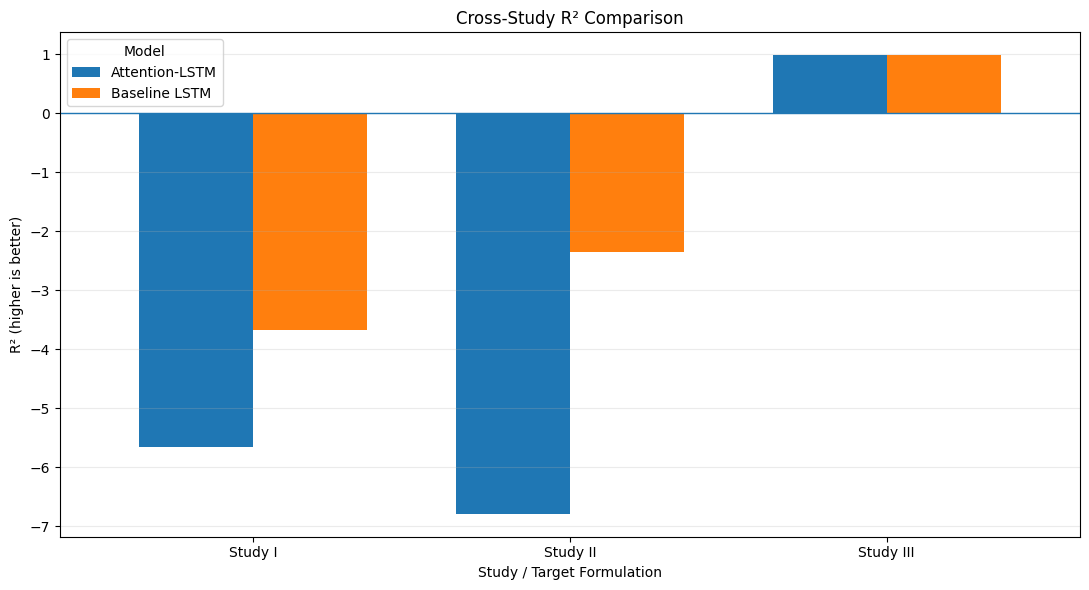

In [77]:
# ============================================================
# Visualization 1: Cross-study R²
# ============================================================

cross_r2 = comparison[
    comparison["Model"].isin(["Baseline LSTM", "Attention-LSTM"])
].pivot(index="Study", columns="Model", values="R2")

ax = cross_r2.plot(
    kind="bar",
    figsize=(11, 6),
    width=0.72
)

ax.axhline(0, linewidth=1)
ax.set_title("Cross-Study R² Comparison")
ax.set_xlabel("Study / Target Formulation")
ax.set_ylabel("R² (higher is better)")
ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", alpha=0.25)
ax.legend(title="Model")

plt.tight_layout()
plt.show()


### Interpretation

The most pronounced change occurs between Studies II and III. Both models move from strongly negative R² values under direct closing-price prediction to approximately **0.985** under the log-return formulation.

This indicates that the **target formulation was a major determinant of forecasting performance** in these experiments.


# Visualization 2 — RMSE within each study

This figure emphasizes the direct model comparison inside each experiment.

Because the scales differ across target formulations, the figure should be interpreted as:

> **Which model is better within a given study?**

rather than as evidence that the absolute RMSE of one study is directly comparable with another.


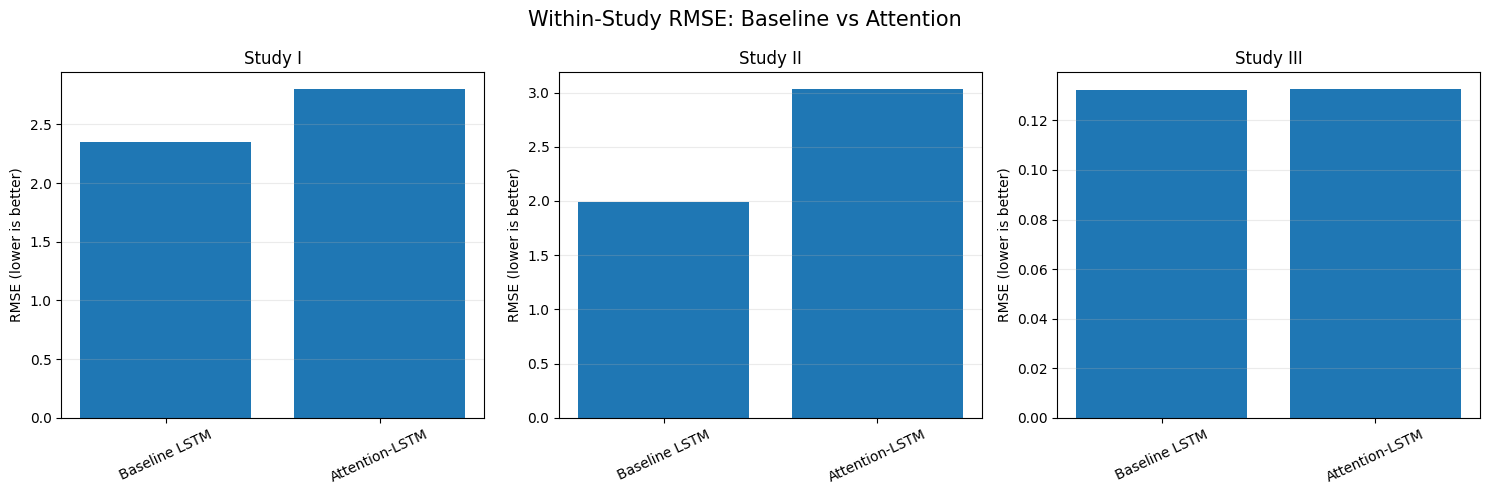

In [78]:
# ============================================================
# Visualization 2: Within-study RMSE
# ============================================================

rmse_df = comparison[
    comparison["Model"].isin(["Baseline LSTM", "Attention-LSTM"])
].copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

for ax, study in zip(axes, ["Study I", "Study II", "Study III"]):
    subset = rmse_df[rmse_df["Study"] == study]
    ax.bar(subset["Model"], subset["RMSE"])
    ax.set_title(f"{study}")
    ax.set_ylabel("RMSE (lower is better)")
    ax.tick_params(axis="x", rotation=25)
    ax.grid(axis="y", alpha=0.25)

fig.suptitle("Within-Study RMSE: Baseline vs Attention", fontsize=15)
plt.tight_layout()
plt.show()


# Visualization 3 — Effect of Adding Attention

The attention mechanism is evaluated against the corresponding **Baseline LSTM**.

For the error metrics, the relative change is calculated as:

$$
\text{Relative Change} =
\frac{\text{Attention} - \text{Baseline}}
{\text{Baseline}}
\times 100
$$

A **positive percentage** means that the error increased, indicating that the attention mechanism made the model performance worse for that metric.

For $R^2$, the difference is calculated directly as:

$$
\Delta R^2 =
R^2_{\text{Attention}} -
R^2_{\text{Baseline}}
$$

In [79]:
# ============================================================
# 7. Calculate attention effect
# ============================================================

effect_rows = []

for study in ["Study I", "Study II", "Study III"]:
    base = comparison[
        (comparison["Study"] == study) &
        (comparison["Model"] == "Baseline LSTM")
    ].iloc[0]

    att = comparison[
        (comparison["Study"] == study) &
        (comparison["Model"] == "Attention-LSTM")
    ].iloc[0]

    effect_rows.append({
        "Study": study,
        "MAE_change_pct": (att["MAE"] - base["MAE"]) / base["MAE"] * 100,
        "RMSE_change_pct": (att["RMSE"] - base["RMSE"]) / base["RMSE"] * 100,
        "MAPE_change_pct": (att["MAPE"] - base["MAPE"]) / base["MAPE"] * 100,
        "R2_difference": att["R2"] - base["R2"],
    })

attention_effect = pd.DataFrame(effect_rows)
attention_effect


,Study,MAE_change_pct,RMSE_change_pct,MAPE_change_pct,R2_difference
0,Study I,22.010607,19.178314,23.803722,-1.966918
1,Study II,63.037667,52.559260,69.772877,-4.441025
2,Study III,7.116048,0.311883,7.883582,-0.000093


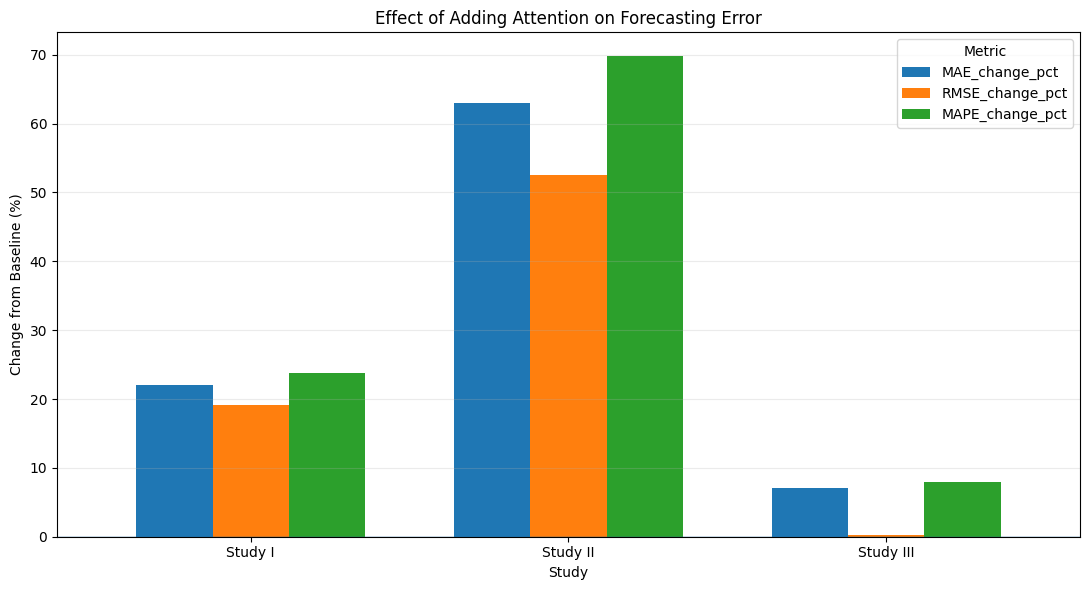

In [80]:
# ============================================================
# 8. Visualization 3: Attention effect
# ============================================================

error_effect = attention_effect.set_index("Study")[
    ["MAE_change_pct", "RMSE_change_pct", "MAPE_change_pct"]
]

ax = error_effect.plot(
    kind="bar",
    figsize=(11, 6),
    width=0.72
)

ax.axhline(0, linewidth=1)
ax.set_title("Effect of Adding Attention on Forecasting Error")
ax.set_xlabel("Study")
ax.set_ylabel("Change from Baseline (%)")
ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", alpha=0.25)
ax.legend(title="Metric")

plt.tight_layout()
plt.show()


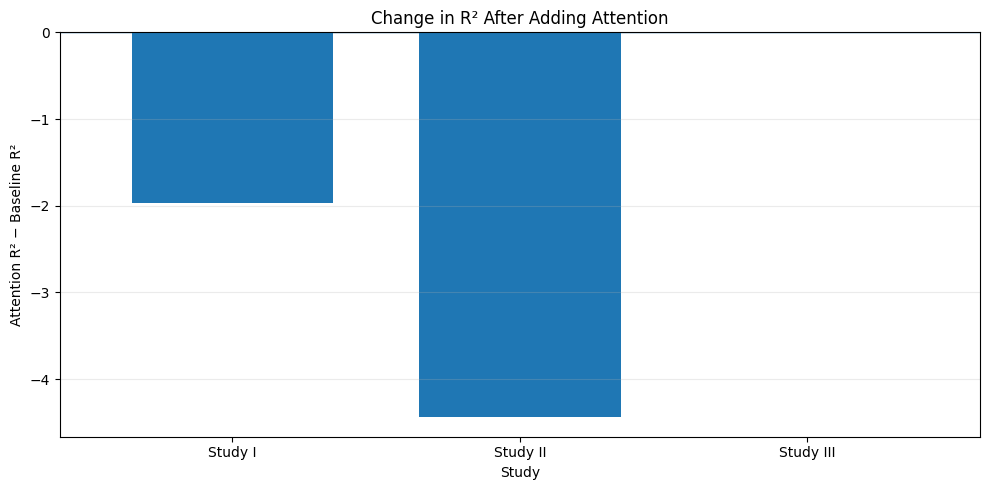

In [81]:
# ============================================================
#  R² effect of attention
# ============================================================

ax = attention_effect.set_index("Study")["R2_difference"].plot(
    kind="bar",
    figsize=(10, 5),
    width=0.7
)

ax.axhline(0, linewidth=1)
ax.set_title("Change in R² After Adding Attention")
ax.set_xlabel("Study")
ax.set_ylabel("Attention R² − Baseline R²")
ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()


### Interpretation

Across all three studies, the attention model does not improve the baseline.

The degradation is substantial in Studies I and II and becomes very small in Study III. Therefore, the evidence supports the conclusion that **attention was not beneficial under the tested configurations**, even though the log-return formulation itself was highly effective.


# Visualization 4 — Study III model comparison

Study III is the final and strongest experimental formulation. It compares:

- Baseline LSTM
- Attention-LSTM
- Naive Current-Close benchmark

The benchmark is important because it asks whether the neural models provide useful predictive information beyond simply carrying today's closing price forward.


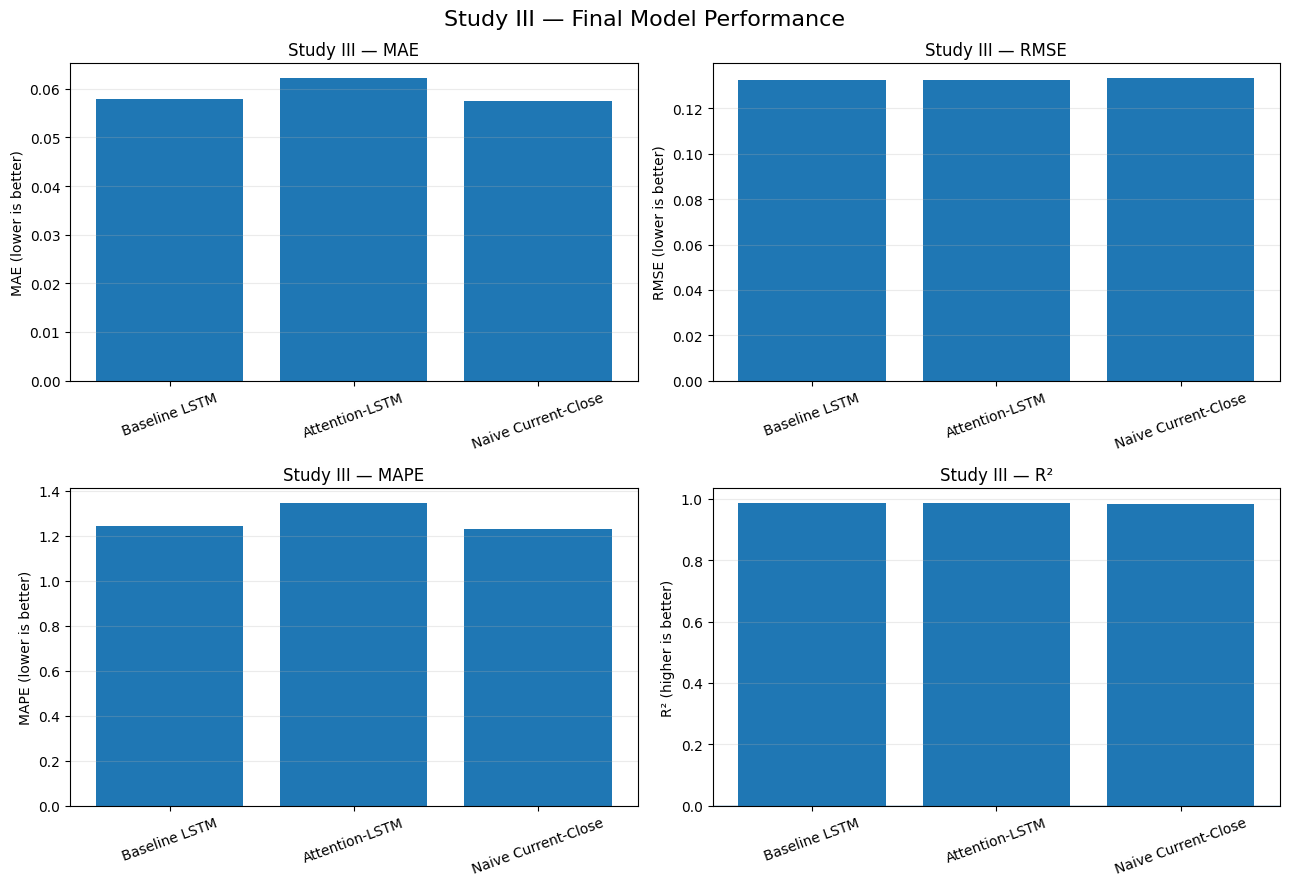

In [82]:
# ============================================================
# Visualization 4: Study III metrics
# ============================================================

study3 = comparison[comparison["Study"] == "Study III"].copy()

metrics = ["MAE", "RMSE", "MAPE", "R2"]
titles = [
    "Study III — MAE",
    "Study III — RMSE",
    "Study III — MAPE",
    "Study III — R²",
]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.ravel()

for ax, metric, title in zip(axes, metrics, titles):
    ax.bar(study3["Model"], study3[metric])
    if metric == "R2":
        ax.axhline(0, linewidth=1)
        ax.set_ylabel("R² (higher is better)")
    else:
        ax.set_ylabel(f"{metric} (lower is better)")
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=20)
    ax.grid(axis="y", alpha=0.25)

fig.suptitle("Study III — Final Model Performance", fontsize=16)
plt.tight_layout()
plt.show()


/tmp/ipykernel_415/2655509305.py:439: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(


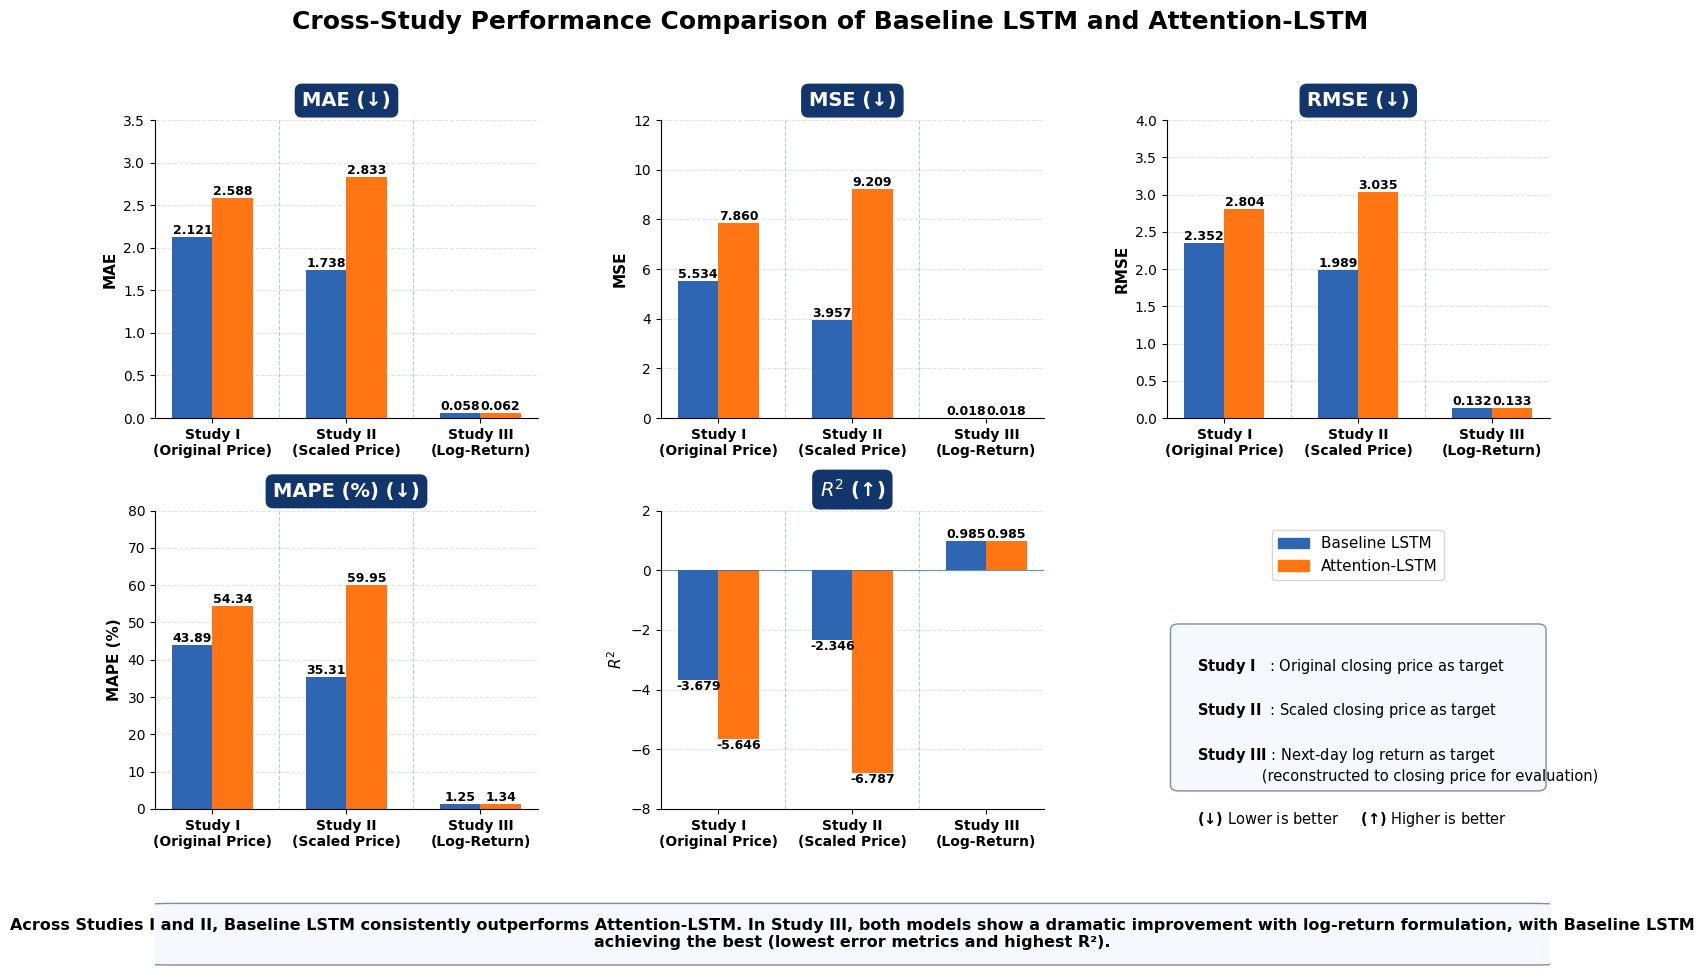

In [83]:
# ============================================================
# Cross-Study Performance Comparison
# Baseline LSTM vs Attention-LSTM
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from matplotlib.gridspec import GridSpec


# ============================================================
# 1. DATA
# ============================================================

studies = [
    "Study I\n(Original Price)",
    "Study II\n(Scaled Price)",
    "Study III\n(Log-Return)"
]

# -------------------------
# Baseline LSTM
# -------------------------
baseline_mae = [2.121, 1.738, 0.058]
baseline_mse = [5.534, 3.957, 0.0175]
baseline_rmse = [2.352, 1.989, 0.132]
baseline_mape = [43.89, 35.31, 1.25]
baseline_r2 = [-3.679, -2.346, 0.985]

# -------------------------
# Attention-LSTM
# -------------------------
attention_mae = [2.588, 2.833, 0.062]
attention_mse = [7.860, 9.209, 0.0176]
attention_rmse = [2.804, 3.035, 0.133]
attention_mape = [54.34, 59.95, 1.34]
attention_r2 = [-5.646, -6.787, 0.985]


# ============================================================
# 2. VISUAL SETTINGS
# ============================================================

# Colors chosen to reproduce the reference figure
baseline_color = "#2F66B3"
attention_color = "#FF7514"
header_color = "#12366B"

# General font
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["font.size"] = 10


# ============================================================
# 3. CREATE FIGURE LAYOUT
# ============================================================

fig = plt.figure(
    figsize=(18, 11),
    facecolor="white"
)

gs = GridSpec(
    nrows=3,
    ncols=3,
    figure=fig,
    height_ratios=[1.0, 1.0, 0.22],
    width_ratios=[1, 1, 1],
    hspace=0.42,
    wspace=0.32
)

# First row
ax_mae = fig.add_subplot(gs[0, 0])
ax_mse = fig.add_subplot(gs[0, 1])
ax_rmse = fig.add_subplot(gs[0, 2])

# Second row
ax_mape = fig.add_subplot(gs[1, 0])
ax_r2 = fig.add_subplot(gs[1, 1])

# Right-hand information panel
ax_info = fig.add_subplot(gs[1, 2])

# Bottom interpretation box
ax_interpretation = fig.add_subplot(gs[2, :])


# ============================================================
# 4. HELPER FUNCTION FOR BAR CHARTS
# ============================================================

def create_comparison_chart(
    ax,
    baseline,
    attention,
    title,
    ylabel,
    ylim=None,
    value_format="{:.3f}"
):
    """
    Create a two-model grouped bar chart.
    """

    x = np.arange(len(studies))
    width = 0.30

    # Baseline LSTM
    bars1 = ax.bar(
        x - width / 2,
        baseline,
        width,
        label="Baseline LSTM",
        color=baseline_color
    )

    # Attention-LSTM
    bars2 = ax.bar(
        x + width / 2,
        attention,
        width,
        label="Attention-LSTM",
        color=attention_color
    )

    # --------------------------------------------------------
    # Axis settings
    # --------------------------------------------------------

    ax.set_xticks(x)
    ax.set_xticklabels(
        studies,
        fontsize=10,
        fontweight="bold"
    )

    ax.set_ylabel(
        ylabel,
        fontsize=11,
        fontweight="bold"
    )

    ax.set_title(
        title,
        fontsize=14,
        fontweight="bold",
        color="white",
        pad=10,
        bbox=dict(
            boxstyle="round,pad=0.35",
            facecolor=header_color,
            edgecolor=header_color
        )
    )

    if ylim is not None:
        ax.set_ylim(ylim)

    # --------------------------------------------------------
    # Grid
    # --------------------------------------------------------

    ax.grid(
        axis="y",
        linestyle="--",
        linewidth=0.8,
        alpha=0.35
    )

    ax.set_axisbelow(True)

    # Vertical separators between studies
    for xpos in [0.5, 1.5]:
        ax.axvline(
            xpos,
            linestyle="--",
            linewidth=0.8,
            alpha=0.35
        )

    # --------------------------------------------------------
    # Remove top/right borders
    # --------------------------------------------------------

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # --------------------------------------------------------
    # Add values above/below bars
    # --------------------------------------------------------

    for bars in [bars1, bars2]:

        for bar in bars:

            height = bar.get_height()

            # Positive values
            if height >= 0:

                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    height,
                    value_format.format(height),
                    ha="center",
                    va="bottom",
                    fontsize=9,
                    fontweight="bold"
                )

            # Negative values
            else:

                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    height,
                    value_format.format(height),
                    ha="center",
                    va="top",
                    fontsize=9,
                    fontweight="bold"
                )


# ============================================================
# 5. MAE
# ============================================================

create_comparison_chart(
    ax_mae,
    baseline_mae,
    attention_mae,
    "MAE (↓)",
    "MAE",
    ylim=(0, 3.5),
    value_format="{:.3f}"
)


# ============================================================
# 6. MSE
# ============================================================

create_comparison_chart(
    ax_mse,
    baseline_mse,
    attention_mse,
    "MSE (↓)",
    "MSE",
    ylim=(0, 12),
    value_format="{:.3f}"
)


# ============================================================
# 7. RMSE
# ============================================================

create_comparison_chart(
    ax_rmse,
    baseline_rmse,
    attention_rmse,
    "RMSE (↓)",
    "RMSE",
    ylim=(0, 4),
    value_format="{:.3f}"
)


# ============================================================
# 8. MAPE
# ============================================================

create_comparison_chart(
    ax_mape,
    baseline_mape,
    attention_mape,
    "MAPE (%) (↓)",
    "MAPE (%)",
    ylim=(0, 80),
    value_format="{:.2f}"
)


# ============================================================
# 9. R²
# ============================================================

create_comparison_chart(
    ax_r2,
    baseline_r2,
    attention_r2,
    r"$R^2$ (↑)",
    r"$R^2$",
    ylim=(-8, 2),
    value_format="{:.3f}"
)

# R² reference line
ax_r2.axhline(
    0,
    linestyle="-",
    linewidth=0.8,
    alpha=0.7
)


# ============================================================
# 10. LEGEND
# ============================================================

# Put legend inside the information panel
legend_handles = [
    plt.Rectangle(
        (0, 0),
        1,
        1,
        color=baseline_color
    ),
    plt.Rectangle(
        (0, 0),
        1,
        1,
        color=attention_color
    )
]

ax_info.legend(
    legend_handles,
    ["Baseline LSTM", "Attention-LSTM"],
    loc="upper center",
    bbox_to_anchor=(0.5, 0.96),
    frameon=True,
    fontsize=11,
    ncol=1
)


# ============================================================
# 11. STUDY INFORMATION BOX
# ============================================================

ax_info.axis("off")

# Information box
info_box = FancyBboxPatch(
    (0.03, 0.08),
    0.94,
    0.52,
    boxstyle="round,pad=0.02",
    linewidth=1,
    edgecolor="#7A8DAA",
    facecolor="#F5F8FC",
    transform=ax_info.transAxes
)

ax_info.add_patch(info_box)

info_text = (
    r"$\bf{Study\ I}$"
    "   : Original closing price as target\n\n"
    r"$\bf{Study\ II}$"
    "  : Scaled closing price as target\n\n"
    r"$\bf{Study\ III}$"
    " : Next-day log return as target\n"
    "              (reconstructed to closing price for evaluation)\n\n"
    r"$\bf{(↓)}$ Lower is better     "
    r"$\bf{(↑)}$ Higher is better"
)

ax_info.text(
    0.08,
    0.51,
    info_text,
    transform=ax_info.transAxes,
    fontsize=10.5,
    verticalalignment="top",
    linespacing=1.4
)


# ============================================================
# 12. MAIN FIGURE TITLE
# ============================================================

fig.suptitle(
    "Cross-Study Performance Comparison of Baseline LSTM and Attention-LSTM",
    fontsize=18,
    fontweight="bold",
    y=0.98
)


# ============================================================
# 13. INTERPRETATION BOX
# ============================================================

ax_interpretation.axis("off")

interpretation_box = FancyBboxPatch(
    (0.015, 0.05),
    0.97,
    0.90,
    boxstyle="round,pad=0.02",
    linewidth=1,
    edgecolor="#7A8DAA",
    facecolor="#F5F8FC",
    transform=ax_interpretation.transAxes
)

ax_interpretation.add_patch(interpretation_box)

interpretation_text = (
    "Across Studies I and II, Baseline LSTM consistently outperforms "
    "Attention-LSTM. In Study III, both models show a dramatic improvement "
    "with log-return formulation, with Baseline LSTM achieving the best "
    "(lowest error metrics and highest R²)."
)

ax_interpretation.text(
    0.5,
    0.5,
    interpretation_text,
    transform=ax_interpretation.transAxes,
    ha="center",
    va="center",
    fontsize=11.5,
    fontweight="bold",
    wrap=True
)


# ============================================================
# 14. FINAL LAYOUT
# ============================================================

plt.tight_layout(
    rect=[0, 0, 1, 0.96]
)

plt.show()

# Visualization 5 — Study III actual vs predicted prices

The Study III prediction files contain the reconstructed next-day closing price for both neural models.

The naive benchmark uses the current close as the next-day prediction.

This visualization focuses on the **complete test-period trajectory**, followed by a zoomed view of the most recent observations.


In [84]:
# ============================================================
#  Load Study III prediction files
# ============================================================

baseline_pred = pd.read_csv(
    RESULT_DIR / "study3_lstm_log_return_predictions.csv"
)

attention_pred = pd.read_csv(
    RESULT_DIR / "study3_attention_lstm_log_return_predictions.csv"
)

baseline_pred["date"] = pd.to_datetime(baseline_pred["date"])
attention_pred["date"] = pd.to_datetime(attention_pred["date"])

pred = baseline_pred[
    ["date", "current_close", "actual_next_close", "predicted_next_close"]
].rename(
    columns={"predicted_next_close": "Baseline LSTM"}
)

pred = pred.merge(
    attention_pred[["date", "predicted_next_close"]],
    on="date",
    how="inner"
).rename(
    columns={"predicted_next_close": "Attention-LSTM"}
)

pred["Naive Current-Close"] = pred["current_close"]

print("Prediction observations:", len(pred))
print("Prediction period:", pred["date"].min().date(), "to", pred["date"].max().date())


Prediction observations: 237
Prediction period: 2025-06-20 to 2026-05-26


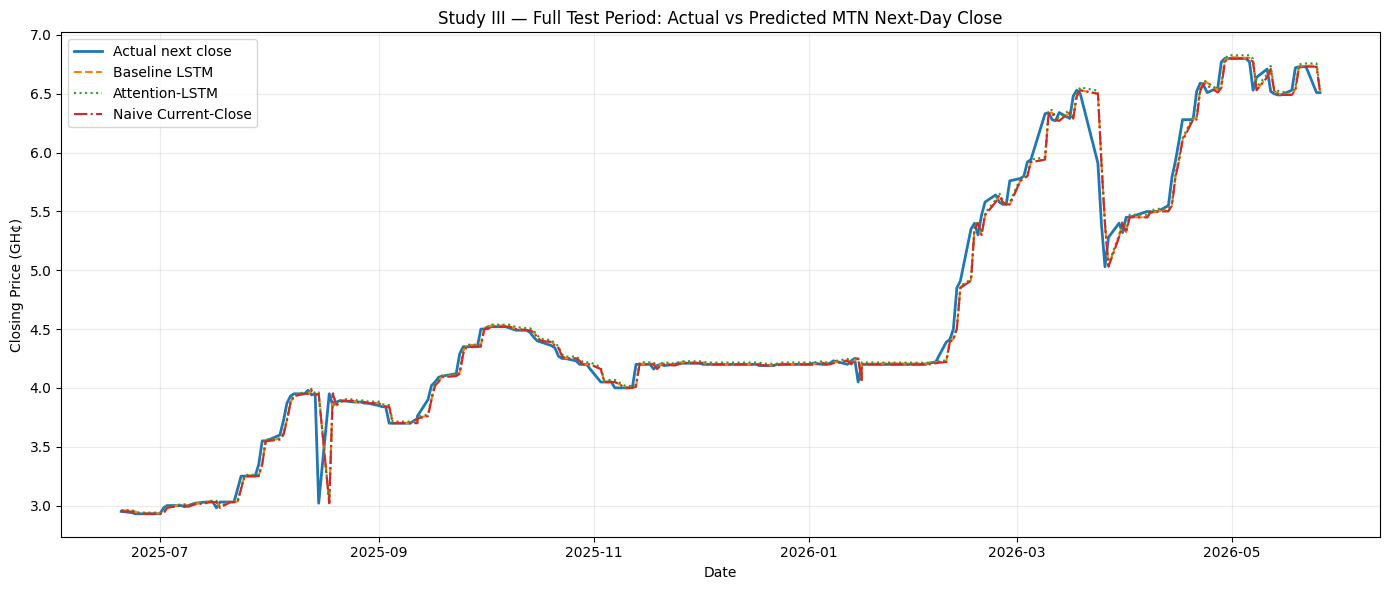

In [85]:
# Full test period
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    pred["date"],
    pred["actual_next_close"],
    label="Actual next close",
    linewidth=2
)

ax.plot(
    pred["date"],
    pred["Baseline LSTM"],
    label="Baseline LSTM",
    linestyle="--"
)

ax.plot(
    pred["date"],
    pred["Attention-LSTM"],
    label="Attention-LSTM",
    linestyle=":"
)

ax.plot(
    pred["date"],
    pred["Naive Current-Close"],
    label="Naive Current-Close",
    linestyle="-."
)

ax.set_title("Study III — Full Test Period: Actual vs Predicted MTN Next-Day Close")
ax.set_xlabel("Date")
ax.set_ylabel("Closing Price (GH¢)")
ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()


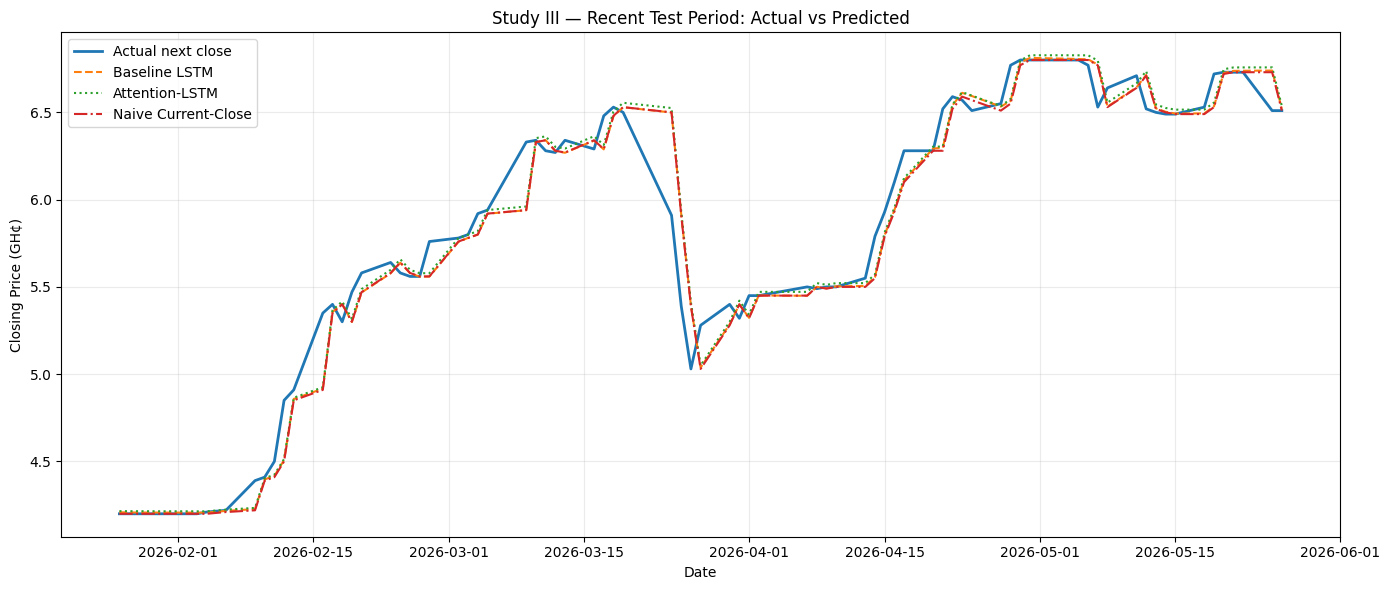

In [86]:
# Recent-period zoom
recent = pred.tail(80)

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    recent["date"],
    recent["actual_next_close"],
    label="Actual next close",
    linewidth=2
)

ax.plot(
    recent["date"],
    recent["Baseline LSTM"],
    label="Baseline LSTM",
    linestyle="--"
)

ax.plot(
    recent["date"],
    recent["Attention-LSTM"],
    label="Attention-LSTM",
    linestyle=":"
)

ax.plot(
    recent["date"],
    recent["Naive Current-Close"],
    label="Naive Current-Close",
    linestyle="-."
)

ax.set_title("Study III — Recent Test Period: Actual vs Predicted")
ax.set_xlabel("Date")
ax.set_ylabel("Closing Price (GH¢)")
ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()


# Visualization 6 — Study III residual comparison

Residuals are calculated as:

$e_t = y_t - \hat{y}_t$

A residual close to zero indicates a small prediction error.

The plot is used to examine whether the two neural models show similar error patterns and whether large deviations occur around particular observations.


In [87]:
# ============================================================
# CROSS-STUDY ACTUAL VS PREDICTED PRICE DATA
# Study I, Study II and Study III
# ============================================================

import os
import sys
import numpy as np
import pandas as pd
import torch

from torch.utils.data import DataLoader

# ------------------------------------------------------------
# Project root
# ------------------------------------------------------------

PROJECT_ROOT = os.path.dirname(RESULT_DIR)

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# ------------------------------------------------------------
# Project modules
# ------------------------------------------------------------

import config as cfg

import utils.preprocessing as prep
from utils.dataset import StockDataset

from models.lstm import StockLSTM
from models.attention_lstm import AttentionLSTM


# ============================================================
# 1. LOAD THE SAME DATA USED BY STUDY I AND STUDY II
# ============================================================

df = prep.load_dataset(
    os.path.join(PROJECT_ROOT, "data", "Final_Dataset.csv")
)

X, y = prep.select_features(df)

(
    X_train,
    X_val,
    X_test,

    y_train,
    y_val,
    y_test

) = prep.split_dataset(
    X,
    y,
    train_size=cfg.TRAIN_RATIO,
    val_size=cfg.VALIDATION_RATIO
)

print("=" * 70)
print("Cross-Study Prediction Reconstruction")
print("=" * 70)

print(f"Dataset Shape       : {df.shape}")
print(f"Feature Shape       : {X.shape}")
print(f"Test Samples        : {len(X_test)}")
print(f"Input Features      : {X.shape[1]}")
print(f"Sequence Length     : {cfg.SEQUENCE_LENGTH}")

Cross-Study Prediction Reconstruction
Dataset Shape       : (1740, 47)
Feature Shape       : (1740, 43)
Test Samples        : 261
Input Features      : 43
Sequence Length     : 30


In [88]:
# ============================================================
# 2. RECONSTRUCT STUDY I / STUDY II PREDICTIONS
# ============================================================

def reconstruct_predictions(
    study_number,
    target_scaling
):
    """
    Reproduce the exact preprocessing and prediction pipeline
    used in Study I or Study II.

    Study I:
        target_scaling = False

    Study II:
        target_scaling = True
    """

    # --------------------------------------------------------
    # Apply the same feature/target scaling used in the study
    # --------------------------------------------------------

    (
        X_train_scaled,
        X_val_scaled,
        X_test_scaled,

        y_train_processed,
        y_val_processed,
        y_test_processed,

        feature_scaler,
        target_scaler

    ) = prep.scale_features(

        X_train,
        X_val,
        X_test,

        y_train,
        y_val,
        y_test,

        target_scaling=target_scaling
    )

    # --------------------------------------------------------
    # Create sequences exactly as in the study notebooks
    # --------------------------------------------------------

    (
        X_train_seq,
        y_train_seq

    ) = prep.create_sequences(
        X_train_scaled,
        y_train_processed,
        cfg.SEQUENCE_LENGTH
    )

    (
        X_val_seq,
        y_val_seq

    ) = prep.create_sequences(
        X_val_scaled,
        y_val_processed,
        cfg.SEQUENCE_LENGTH
    )

    (
        X_test_seq,
        y_test_seq

    ) = prep.create_sequences(
        X_test_scaled,
        y_test_processed,
        cfg.SEQUENCE_LENGTH
    )

    # --------------------------------------------------------
    # Test DataLoader
    # --------------------------------------------------------

    test_dataset = StockDataset(
        X_test_seq,
        y_test_seq
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=cfg.BATCH_SIZE,
        shuffle=False
    )

    # --------------------------------------------------------
    # Helper for loading a model
    # --------------------------------------------------------

    def load_model(model_type):

        if model_type == "baseline":

            model = StockLSTM(

                input_size=X_test_seq.shape[2],

                hidden_size=cfg.HIDDEN_SIZE,

                num_layers=cfg.NUM_LAYERS,

                dropout=cfg.DROPOUT,

                fc_units=cfg.FC_UNITS,

                output_size=cfg.OUTPUT_SIZE

            ).to(cfg.DEVICE)

            model_path = os.path.join(
                PROJECT_ROOT,
                "saved_models",
                f"study{study_number}_baseline.pth"
            )

        else:

            model = AttentionLSTM(
                input_size=X_test_seq.shape[2]
            ).to(cfg.DEVICE)

            model_path = os.path.join(
                PROJECT_ROOT,
                "saved_models",
                f"study{study_number}_attention.pth"
            )

        # Load best checkpoint
        state_dict = torch.load(
            model_path,
            map_location=cfg.DEVICE
        )

        model.load_state_dict(
            state_dict
        )

        model.eval()

        return model

    # --------------------------------------------------------
    # Generate predictions
    # --------------------------------------------------------

    predictions = {}
    attention_weights_output = np.array([]) # Initialize for attention weights

    for model_type in [
        "baseline",
        "attention"
    ]:

        model = load_model(
            model_type
        )

        model_predictions = []
        current_attention_weights = [] # To store weights for this model_type

        with torch.no_grad():

            for inputs, _ in test_loader:

                inputs = inputs.to(
                    cfg.DEVICE
                )

                outputs = model(
                    inputs
                )

                # Attention-LSTM returns: prediction, attention_weights
                if isinstance(
                    outputs,
                    tuple
                ):

                    model_predictions.append(
                        outputs[0]
                        .cpu()
                        .numpy()
                        .reshape(-1)
                    )
                    # Capture attention weights only for the attention model
                    if model_type == "attention":
                        current_attention_weights.append(
                            outputs[1].cpu().numpy()
                        )
                else:

                    model_predictions.append(
                        outputs
                        .cpu()
                        .numpy()
                        .reshape(-1)
                    )

        predictions[model_type] = np.concatenate(
            model_predictions
        )
        if model_type == "attention" and len(current_attention_weights) > 0:
            attention_weights_output = np.concatenate(current_attention_weights, axis=0)

    # --------------------------------------------------------
    # Actual target
    # --------------------------------------------------------

    actual = np.asarray(
        y_test_seq
    ).reshape(-1)

    # --------------------------------------------------------
    # Reverse target scaling for Study II
    # --------------------------------------------------------

    if target_scaling:

        actual = target_scaler.inverse_transform(
            actual.reshape(-1, 1)
        ).reshape(-1)

        predictions["baseline"] = (
            target_scaler.inverse_transform(
                predictions["baseline"].reshape(-1, 1)
            ).reshape(-1)
        )

        predictions["attention"] = (
            target_scaler.inverse_transform(
                predictions["attention"].reshape(-1, 1)
            ).reshape(-1)
        )

    # --------------------------------------------------------
    # Return
    # --------------------------------------------------------

    return (
        actual,
        predictions["baseline"],
        predictions["attention"],
        attention_weights_output # Return the captured attention weights
    )


In [89]:
# ============================================================
# 3. STUDY I
# ============================================================

study1_actual, study1_baseline, study1_attention_pred, study1_attention_weights_data = (
    reconstruct_predictions(
        study_number=1,
        target_scaling=False
    )
)

print("\nStudy I")
print("-" * 50)

print(
    "Actual shape           :",
    study1_actual.shape
)

print(
    "Baseline prediction    :",
    study1_baseline.shape
)

print(
    "Attention prediction   :",
    study1_attention_pred.shape
)

print(
    "Actual range           :",
    f"{study1_actual.min():.4f} → {study1_actual.max():.4f}"
)

print(
    "Baseline range         :",
    f"{study1_baseline.min():.4f} → {study1_baseline.max():.4f}"
)

print(
    "Attention range        :",
    f"{study1_attention_pred.min():.4f} → {study1_attention_pred.max():.4f}"
)



Study I
--------------------------------------------------
Actual shape           : (231,)
Baseline prediction    : (231,)
Attention prediction   : (231,)
Actual range           : 2.9300 → 6.8000
Baseline range         : 2.2717 → 2.5647
Attention range        : 1.9372 → 2.0176


In [90]:
# ============================================================
# 4. STUDY II
# ============================================================

study2_actual, study2_baseline, study2_attention_pred, study2_attention_weights_data = (
    reconstruct_predictions(
        study_number=2,
        target_scaling=True
    )
)

print("\nStudy II")
print("-" * 50)

print(
    "Actual shape           :",
    study2_actual.shape
)

print(
    "Baseline prediction    :",
    study2_baseline.shape
)

print(
    "Attention prediction   :",
    study2_attention_pred.shape
)

print(
    "Actual range           :",
    f"{study2_actual.min():.4f} → {study2_actual.max():.4f}"
)

print(
    "Baseline range         :",
    f"{study2_baseline.min():.4f} → {study2_baseline.max():.4f}"
)

print(
    "Attention range        :",
    f"{study2_attention_pred.min():.4f} → {study2_attention_pred.max():.4f}"
)



Study II
--------------------------------------------------
Actual shape           : (231,)
Baseline prediction    : (231,)
Attention prediction   : (231,)
Actual range           : 2.9300 → 6.8000
Baseline range         : 2.5574 → 3.0540
Attention range        : 1.7144 → 1.7524


In [91]:
# ============================================================
# 5. LOAD STUDY III PREDICTIONS
# ============================================================

study3_baseline = pd.read_csv(
    os.path.join(
        RESULT_DIR,
        "study3_lstm_log_return_predictions.csv"
    )
)

study3_attention = pd.read_csv(
    os.path.join(
        RESULT_DIR,
        "study3_attention_lstm_log_return_predictions.csv"
    )
)

study3_baseline["date"] = pd.to_datetime(
    study3_baseline["date"]
)

study3_attention["date"] = pd.to_datetime(
    study3_attention["date"]
)

# ------------------------------------------------------------
# Align the two Study III prediction files
# ------------------------------------------------------------

study3 = study3_baseline[
    [
        "date",
        "actual_next_close",
        "predicted_next_close"
    ]
].copy()

study3.rename(
    columns={
        "predicted_next_close":
        "Baseline LSTM"
    },
    inplace=True
)

study3 = study3.merge(
    study3_attention[
        [
            "date",
            "predicted_next_close"
        ]
    ],
    on="date",
    how="inner"
)

study3.rename(
    columns={
        "predicted_next_close":
        "Attention-LSTM"
    },
    inplace=True
)

print("\nStudy III")
print("-" * 50)

print(
    "Prediction observations:",
    len(study3)
)

print(
    "Prediction period:",
    study3["date"].min().date(),
    "to",
    study3["date"].max().date()
)


Study III
--------------------------------------------------
Prediction observations: 237
Prediction period: 2025-06-20 to 2026-05-26


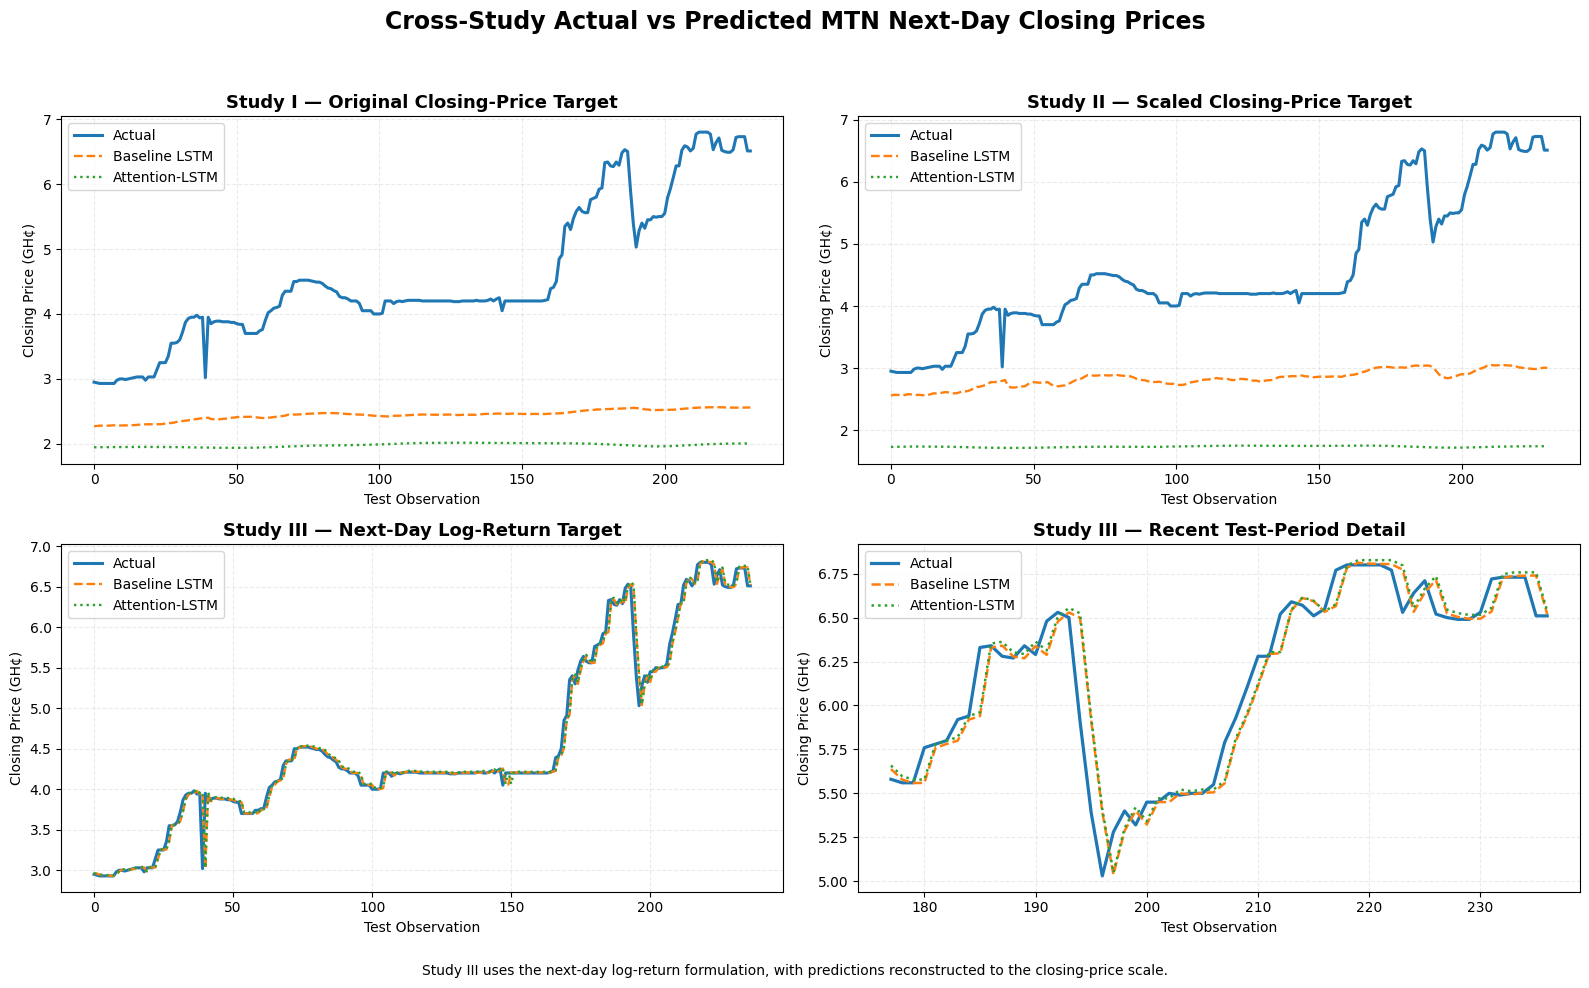

In [92]:
# ============================================================
# 6. CROSS-STUDY ACTUAL VS PREDICTED PRICE VISUALIZATION
# ============================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(16, 10)
)

axes = axes.flatten()


# ============================================================
# STUDY I
# ============================================================

ax = axes[0]

x1 = np.arange(
    len(study1_actual)
)

ax.plot(
    x1,
    study1_actual,
    linewidth=2.2,
    label="Actual"
)

ax.plot(
    x1,
    study1_baseline,
    linestyle="--",
    linewidth=1.7,
    label="Baseline LSTM"
)

ax.plot(
    x1,
    study1_attention_pred,
    linestyle=":",
    linewidth=1.7,
    label="Attention-LSTM"
)

ax.set_title(
    "Study I — Original Closing-Price Target",
    fontsize=13,
    fontweight="bold"
)

ax.set_xlabel(
    "Test Observation"
)

ax.set_ylabel(
    "Closing Price (GH¢)"
)

ax.grid(
    linestyle="--",
    alpha=0.25
)

ax.legend()


# ============================================================
# STUDY II
# ============================================================

ax = axes[1]

x2 = np.arange(
    len(study2_actual)
)

ax.plot(
    x2,
    study2_actual,
    linewidth=2.2,
    label="Actual"
)

ax.plot(
    x2,
    study2_baseline,
    linestyle="--",
    linewidth=1.7,
    label="Baseline LSTM"
)

ax.plot(
    x2,
    study2_attention_pred,
    linestyle=":",
    linewidth=1.7,
    label="Attention-LSTM"
)

ax.set_title(
    "Study II — Scaled Closing-Price Target",
    fontsize=13,
    fontweight="bold"
)

ax.set_xlabel(
    "Test Observation"
)

ax.set_ylabel(
    "Closing Price (GH¢)"
)

ax.grid(
    linestyle="--",
    alpha=0.25
)

ax.legend()


# ============================================================
# STUDY III
# ============================================================

ax = axes[2]

x3 = np.arange(
    len(study3)
)

ax.plot(
    x3,
    study3["actual_next_close"],
    linewidth=2.2,
    label="Actual"
)

ax.plot(
    x3,
    study3["Baseline LSTM"],
    linestyle="--",
    linewidth=1.7,
    label="Baseline LSTM"
)

ax.plot(
    x3,
    study3["Attention-LSTM"],
    linestyle=":",
    linewidth=1.7,
    label="Attention-LSTM"
)

ax.set_title(
    "Study III — Next-Day Log-Return Target",
    fontsize=13,
    fontweight="bold"
)

ax.set_xlabel(
    "Test Observation"
)

ax.set_ylabel(
    "Closing Price (GH¢)"
)

ax.grid(
    linestyle="--",
    alpha=0.25
)

ax.legend()


# ============================================================
# STUDY III — RECENT PERIOD
# ============================================================

ax = axes[3]

recent = study3.tail(60)

ax.plot(
    recent.index,
    recent["actual_next_close"],
    linewidth=2.3,
    label="Actual"
)

ax.plot(
    recent.index,
    recent["Baseline LSTM"],
    linestyle="--",
    linewidth=1.8,
    label="Baseline LSTM"
)

ax.plot(
    recent.index,
    recent["Attention-LSTM"],
    linestyle=":",
    linewidth=1.8,
    label="Attention-LSTM"
)

ax.set_title(
    "Study III — Recent Test-Period Detail",
    fontsize=13,
    fontweight="bold"
)

ax.set_xlabel(
    "Test Observation"
)

ax.set_ylabel(
    "Closing Price (GH¢)"
)

ax.grid(
    linestyle="--",
    alpha=0.25
)

ax.legend()


# ============================================================
# OVERALL TITLE
# ============================================================

fig.suptitle(
    "Cross-Study Actual vs Predicted MTN Next-Day Closing Prices",
    fontsize=17,
    fontweight="bold"
)


# ============================================================
# EXPLANATORY NOTE
# ============================================================

fig.text(
    0.5,
    0.015,
    "Study III uses the next-day log-return formulation, "
    "with predictions reconstructed to the closing-price scale.",
    ha="center",
    fontsize=10
)


# ============================================================
# FINAL FORMATTING
# ============================================================

plt.tight_layout(
    rect=[0, 0.04, 1, 0.95]
)

plt.show()

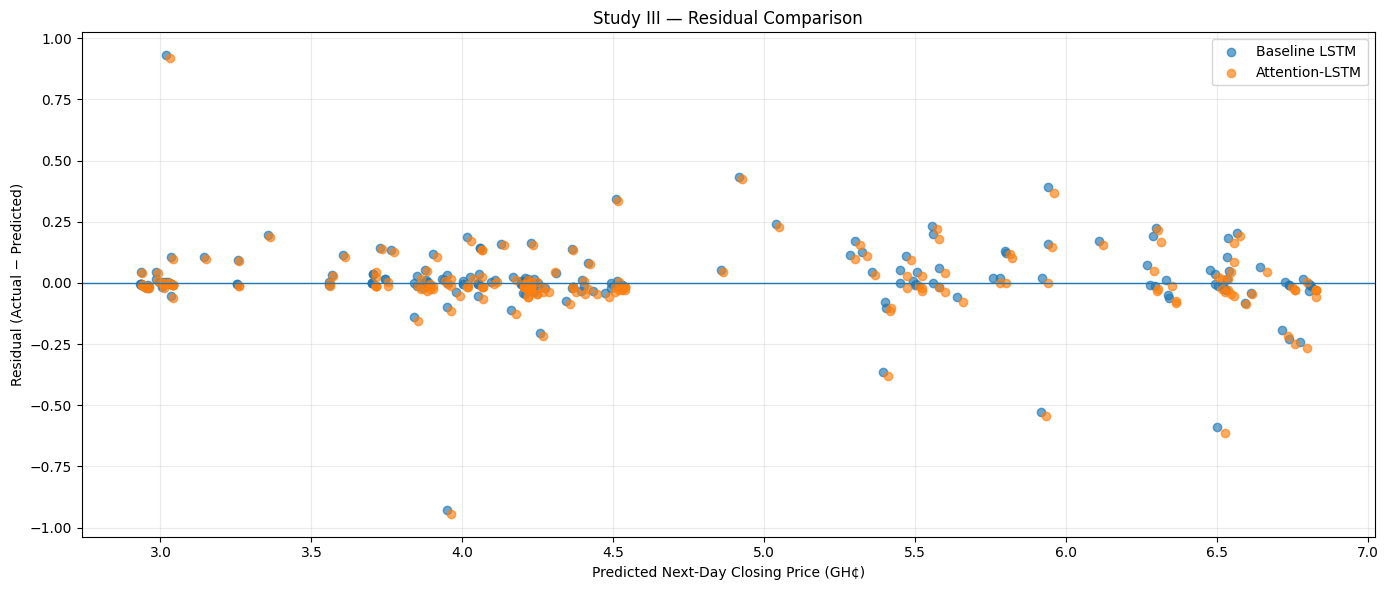

In [93]:
# ============================================================
# Study III residual comparison
# ============================================================

pred["Baseline residual"] = (
    pred["actual_next_close"] - pred["Baseline LSTM"]
)

pred["Attention residual"] = (
    pred["actual_next_close"] - pred["Attention-LSTM"]
)

fig, ax = plt.subplots(figsize=(14, 6))

ax.scatter(
    pred["Baseline LSTM"],
    pred["Baseline residual"],
    alpha=0.65,
    label="Baseline LSTM"
)

ax.scatter(
    pred["Attention-LSTM"],
    pred["Attention residual"],
    alpha=0.65,
    label="Attention-LSTM"
)

ax.axhline(0, linewidth=1)

ax.set_title("Study III — Residual Comparison")
ax.set_xlabel("Predicted Next-Day Closing Price (GH¢)")
ax.set_ylabel("Residual (Actual − Predicted)")
ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()


# Visualization 7 — Training and validation loss across studies

The stored history files are used to examine optimization behaviour.

The loss values are **training-space losses** and therefore should not be confused with the final reconstructed closing-price metrics reported in the model comparison.

Study II and Study III histories use the naming convention stored by their respective training routines, so the notebook normalizes the column names only for plotting.


In [94]:
# ============================================================
# Load and normalize training histories
# ============================================================

def load_history(filename, study, model):
    df = pd.read_csv(RESULT_DIR / filename).copy()

    # Normalize column names used by different study training routines.
    rename_map = {
        "Epoch": "epoch",
        "train_loss": "train_loss",
        "Train Loss": "train_loss",
        "val_loss": "val_loss",
        "Validation Loss": "val_loss",
        "learning_rate": "learning_rate",
        "Learning Rate": "learning_rate",
    }
    df = df.rename(columns=rename_map)

    if "epoch" not in df.columns:
        df["epoch"] = np.arange(1, len(df) + 1)

    df["Study"] = study
    df["Model"] = model

    return df

histories = pd.concat([
    load_history("study1_baseline_history.csv", "Study I", "Baseline LSTM"),
    load_history("study1_attention_history.csv", "Study I", "Attention-LSTM"),
    load_history("study2_baseline.csv", "Study II", "Baseline LSTM")
], ignore_index=True) if False else None

# Load the actual history files for each study.
history_files = [
    ("study1_baseline_history.csv", "Study I", "Baseline LSTM"),
    ("study1_attention_history.csv", "Study I", "Attention-LSTM"),
    ("study2_attention_history.csv", "Study II", "Attention-LSTM"),
    ("study3_lstm_log_return_history.csv", "Study III", "Baseline LSTM"),
    ("study3_attention_lstm_log_return_history.csv", "Study III", "Attention-LSTM"),
]

# Study II baseline history is not stored during the training section.
# Its final performance remains available in study2_baseline.csv.
history_list = [
    load_history(filename, study, model)
    for filename, study, model in history_files
]

histories = pd.concat(history_list, ignore_index=True)

print("History files loaded:")
print(
    histories.groupby(["Study", "Model"])
    .size()
    .rename("epochs")
    .reset_index()
)


History files loaded:
       Study           Model  epochs
0    Study I  Attention-LSTM      20
1    Study I   Baseline LSTM      27
2   Study II  Attention-LSTM      18
3  Study III  Attention-LSTM      13
4  Study III   Baseline LSTM      12


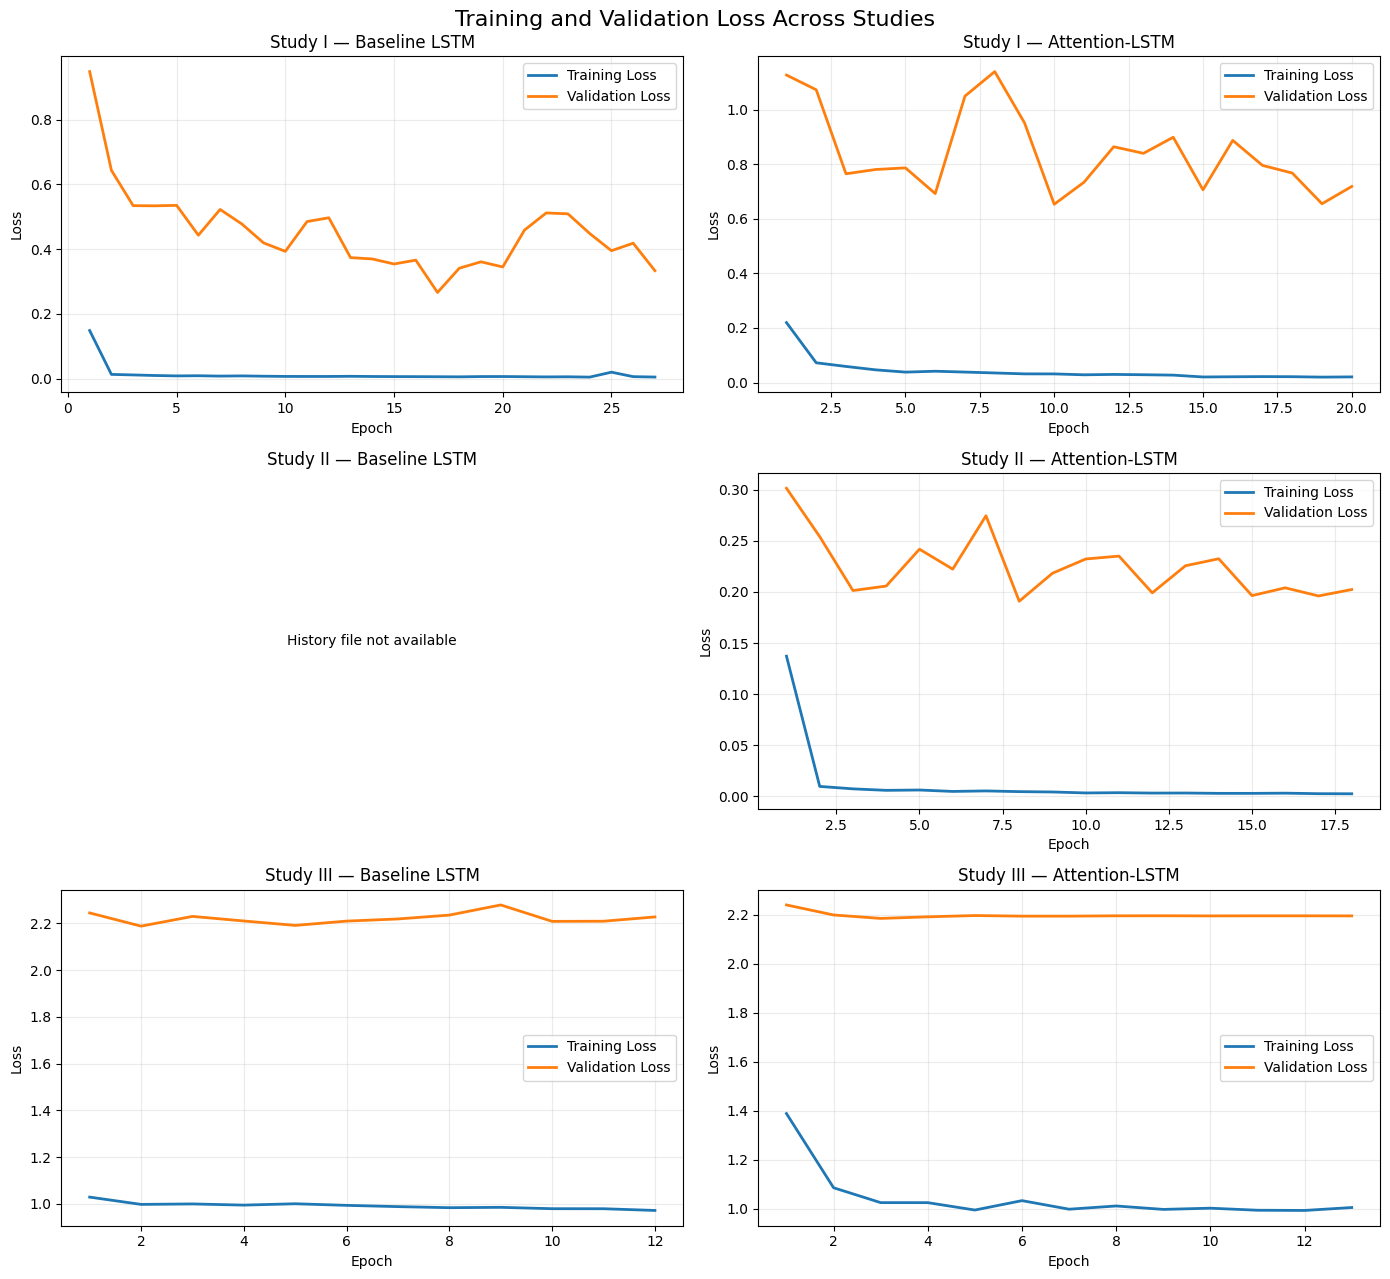

In [95]:
# ============================================================
# 14. Training/validation loss panels
# ============================================================

fig, axes = plt.subplots(3, 2, figsize=(14, 13))

for row, study in enumerate(["Study I", "Study II", "Study III"]):
    for col, model in enumerate(["Baseline LSTM", "Attention-LSTM"]):
        ax = axes[row, col]
        subset = histories[
            (histories["Study"] == study) &
            (histories["Model"] == model)
        ]

        if subset.empty:
            ax.text(
                0.5, 0.5,
                "History file not available",
                ha="center",
                va="center",
                transform=ax.transAxes
            )
            ax.set_title(f"{study} — {model}")
            ax.set_axis_off()
            continue

        ax.plot(
            subset["epoch"],
            subset["train_loss"],
            label="Training Loss",
            linewidth=2
        )

        ax.plot(
            subset["epoch"],
            subset["val_loss"],
            label="Validation Loss",
            linewidth=2
        )

        ax.set_title(f"{study} — {model}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.grid(alpha=0.25)
        ax.legend()

fig.suptitle("Training and Validation Loss Across Studies", fontsize=16)
plt.tight_layout()
plt.show()


# Visualization 8 — Learning-rate schedules

The stored histories also contain the learning rate used during training.

This visualization makes the optimization schedule distinguishable from the loss curves and helps document when learning-rate reductions occurred.


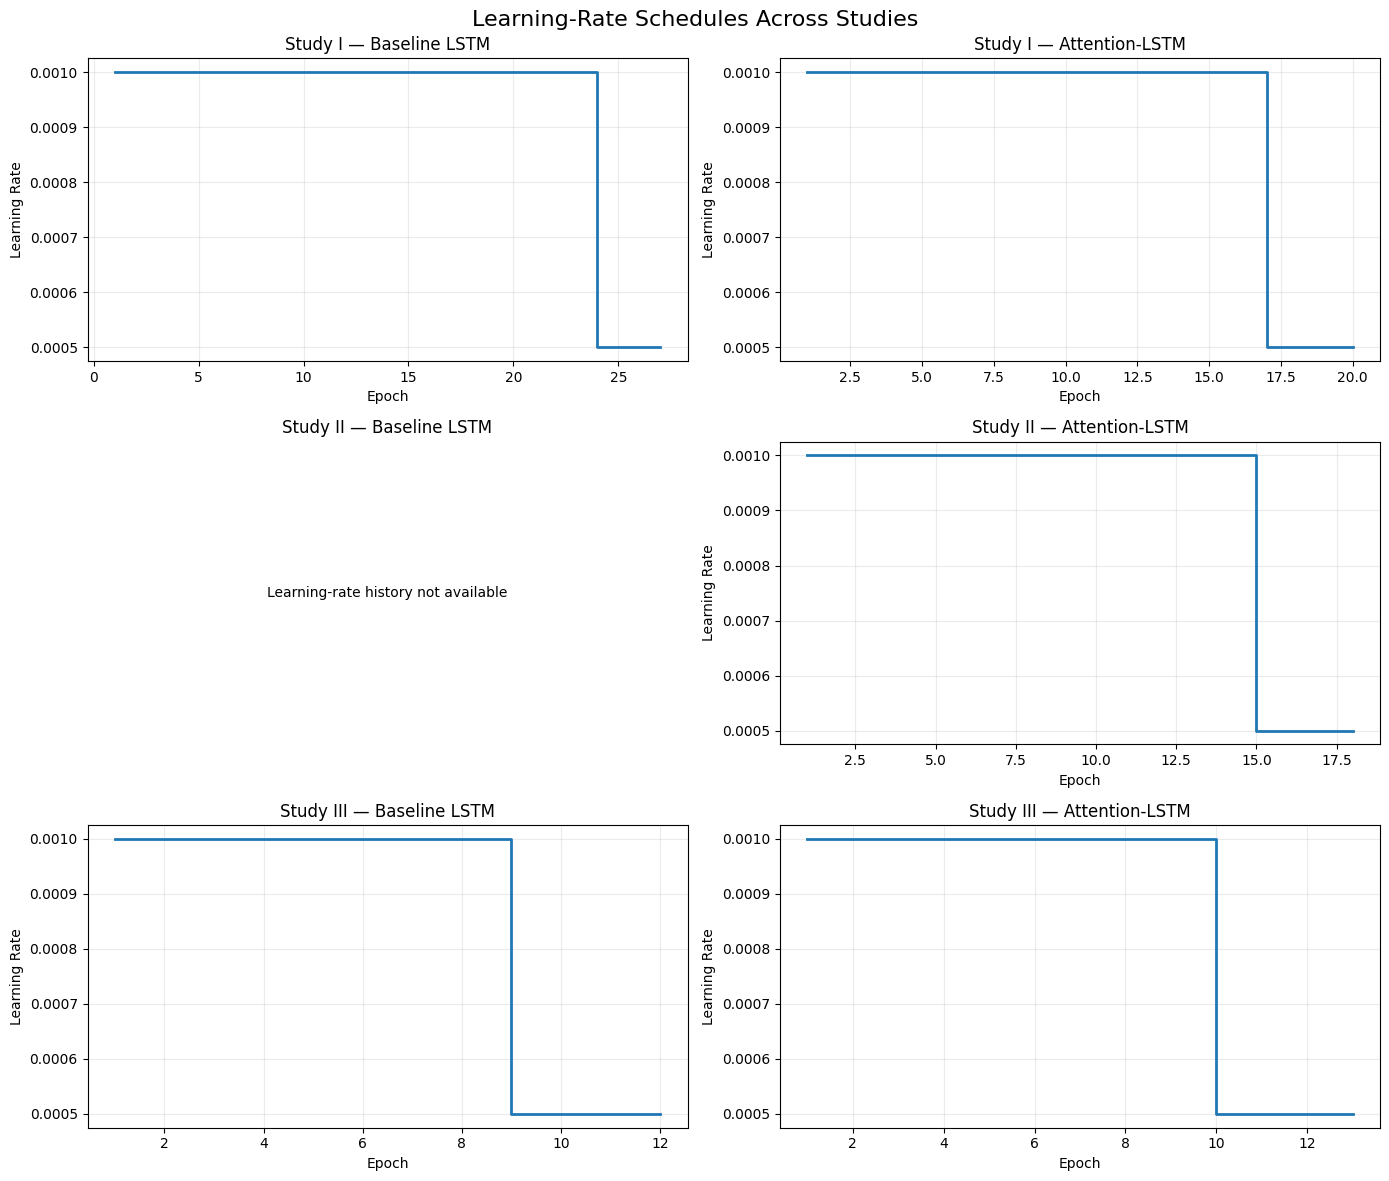

In [96]:
# ============================================================
# Learning-rate schedules
# ============================================================

fig, axes = plt.subplots(3, 2, figsize=(14, 12))

for row, study in enumerate(["Study I", "Study II", "Study III"]):
    for col, model in enumerate(["Baseline LSTM", "Attention-LSTM"]):
        ax = axes[row, col]
        subset = histories[
            (histories["Study"] == study) &
            (histories["Model"] == model)
        ]

        if subset.empty or "learning_rate" not in subset.columns:
            ax.text(
                0.5, 0.5,
                "Learning-rate history not available",
                ha="center",
                va="center",
                transform=ax.transAxes
            )
            ax.set_title(f"{study} — {model}")
            ax.set_axis_off()
            continue

        ax.step(
            subset["epoch"],
            subset["learning_rate"],
            where="post",
            linewidth=2
        )

        ax.set_title(f"{study} — {model}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Learning Rate")
        ax.grid(alpha=0.25)

fig.suptitle("Learning-Rate Schedules Across Studies", fontsize=16)
plt.tight_layout()
plt.show()


In [97]:
# ============================================================
# STUDY III — LOAD SAVED ATTENTION-LSTM CHECKPOINT
# AND EXTRACT ACTUAL ATTENTION WEIGHTS
# ============================================================

import os
import numpy as np
import torch
from pathlib import Path

print("=" * 70)
print("Study III — Attention Weight Extraction from Saved Checkpoint")
print("=" * 70)

# ------------------------------------------------------------
# IMPORTANT
# ------------------------------------------------------------
# Study III uses the SAME Attention-LSTM architecture and
# 30-step sequence length as Studies I and II.
# ------------------------------------------------------------

STUDY3_SEQUENCE_LENGTH = 30

# ------------------------------------------------------------
# Checkpoint
# ------------------------------------------------------------

study3_checkpoint = os.path.join(
    PROJECT_ROOT,
    "saved_models", # Added 'saved_models' directory
    "study3_attention_lstm_log_return.pth"
)

print("Checkpoint:")
print(study3_checkpoint)

if not os.path.exists(study3_checkpoint):
    raise FileNotFoundError(
        f"Study III checkpoint not found:\n{study3_checkpoint}"
    )

print("\nCheckpoint found.")


# ============================================================
# BUILD THE STUDY III ATTENTION MODEL
# ============================================================

study3_attention_model = AttentionLSTM(
    input_size=X3_test_seq.shape[2]
).to(cfg.DEVICE)


# ============================================================
# LOAD SAVED BEST MODEL
# ============================================================

checkpoint = torch.load(
    study3_checkpoint,
    map_location=cfg.DEVICE
)

study3_attention_model.load_state_dict(
    checkpoint
)

study3_attention_model.eval()

print("Study III Attention-LSTM checkpoint loaded.")


# ============================================================
# EXTRACT ATTENTION WEIGHTS DIRECTLY
# ============================================================

study3_attention_model.eval()

study3_attention_batches = []

with torch.no_grad():

    for inputs, _ in test_loader3:

        inputs = inputs.to(cfg.DEVICE)

        outputs = study3_attention_model(
            inputs
        )

        # Attention-LSTM returns:
        #
        # prediction, attention_weights
        #
        predictions_batch = outputs[0]
        attention_batch = outputs[1]

        study3_attention_batches.append(
            attention_batch.cpu().numpy()
        )


# ============================================================
# COMBINE BATCHES
# ============================================================

study3_attention = np.concatenate(
    study3_attention_batches,
    axis=0
)

# Remove final singleton dimension if present
study3_attention = np.squeeze(
    study3_attention
)


# ============================================================
# VERIFY
# ============================================================

print("\n" + "=" * 70)
print("Study III Attention Verification")
print("=" * 70)

print(
    "Attention Weight Shape :",
    study3_attention.shape
)

print(
    "Minimum Weight         :",
    f"{study3_attention.min():.9f}"
)

print(
    "Maximum Weight         :",
    f"{study3_attention.max():.9f}"
)

row_sums = study3_attention.sum(axis=1)

print(
    "Minimum Row Sum        :",
    f"{row_sums.min():.9f}"
)

print(
    "Maximum Row Sum        :",
    f"{row_sums.max():.9f}"
)

print(
    "Mean Row Sum           :",
    f"{row_sums.mean():.9f}"
)

print(
    "Expected Row Sum       : 1.000000"
)

print(
    "Normalization Valid    :",
    np.allclose(
        row_sums,
        1.0,
        atol=1e-6
    )
)

Study III — Attention Weight Extraction from Saved Checkpoint
Checkpoint:
/content/drive/MyDrive/DL_Sem_Project/saved_models/study3_attention_lstm_log_return.pth

Checkpoint found.
Study III Attention-LSTM checkpoint loaded.

Study III Attention Verification
Attention Weight Shape : (231, 30)
Minimum Weight         : 0.027977742
Maximum Weight         : 0.034895938
Minimum Row Sum        : 0.999999762
Maximum Row Sum        : 1.000000238
Mean Row Sum           : 1.000000000
Expected Row Sum       : 1.000000
Normalization Valid    : True


FINAL CROSS-STUDY ATTENTION VERIFICATION
Study I    : Shape = (231, 30, 1), Row Sum = 1.000000
Study II   : Shape = (231, 30, 1), Row Sum = 1.000000
Study III  : Shape = (231, 30), Row Sum = 1.000000


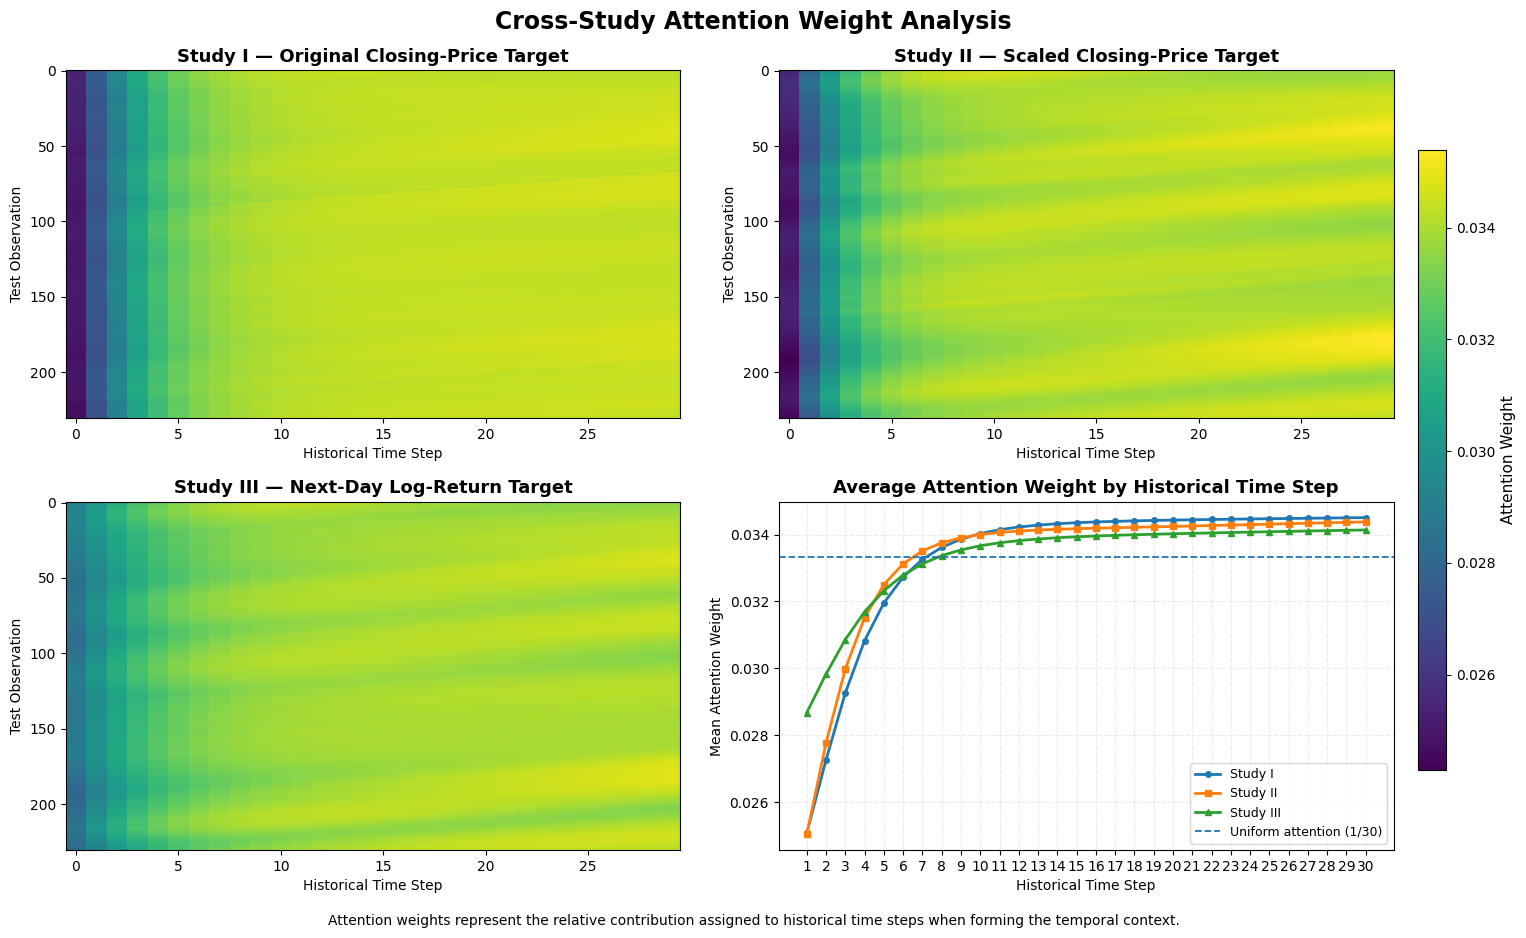

In [100]:
# ============================================================
# CROSS-STUDY ATTENTION WEIGHT ANALYSIS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. FINAL SHAPE VERIFICATION
# ============================================================

attention_data = {
    "Study I": study1_attention_weights_data,
    "Study II": study2_attention_weights_data,
    "Study III": study3_attention
}

print("=" * 70)
print("FINAL CROSS-STUDY ATTENTION VERIFICATION")
print("=" * 70)

for study_name, weights in attention_data.items():

    print(
        f"{study_name:<10} : "
        f"Shape = {weights.shape}, "
        f"Row Sum = {weights.sum(axis=1).mean():.6f}"
    )


# ============================================================
# 2. DETERMINE COMMON SCALE AND TIME STEPS
# ============================================================

vmin = min(
    weights.min()
    for weights in attention_data.values()
)

vmax = max(
    weights.max()
    for weights in attention_data.values()
)

# Number of historical time steps
n_steps = study1_attention_weights_data.shape[1]

steps = np.arange(1, n_steps + 1)


# ============================================================
# 3. CALCULATE CROSS-STUDY MEAN ATTENTION
# ============================================================

mean1 = study1_attention_weights_data.mean(axis=0)
mean2 = study2_attention_weights_data.mean(axis=0)
mean3 = study3_attention.mean(axis=0)

# Uniform attention reference
uniform_attention = 1 / n_steps


# ============================================================
# 4. CREATE ORGANIZED FIGURE
# ============================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(16, 10)
)

# Keep the main plots compact and leave space
# on the right for a dedicated colorbar.
fig.subplots_adjust(
    left=0.07,
    right=0.90,
    bottom=0.10,
    top=0.88,
    wspace=0.16,
    hspace=0.24
)


# ============================================================
# STUDY I — ORIGINAL CLOSING PRICE
# ============================================================

im1 = axes[0, 0].imshow(
    study1_attention_weights_data,
    aspect="auto",
    interpolation="nearest",
    cmap="viridis",
    vmin=vmin,
    vmax=vmax
)

axes[0, 0].set_title(
    "Study I — Original Closing-Price Target",
    fontsize=13,
    fontweight="bold"
)

axes[0, 0].set_xlabel(
    "Historical Time Step"
)

axes[0, 0].set_ylabel(
    "Test Observation"
)


# ============================================================
# STUDY II — SCALED CLOSING PRICE
# ============================================================

axes[0, 1].imshow(
    study2_attention_weights_data,
    aspect="auto",
    interpolation="nearest",
    cmap="viridis",
    vmin=vmin,
    vmax=vmax
)

axes[0, 1].set_title(
    "Study II — Scaled Closing-Price Target",
    fontsize=13,
    fontweight="bold"
)

axes[0, 1].set_xlabel(
    "Historical Time Step"
)

axes[0, 1].set_ylabel(
    "Test Observation"
)


# ============================================================
# STUDY III — NEXT-DAY LOG RETURN
# ============================================================

axes[1, 0].imshow(
    study3_attention,
    aspect="auto",
    interpolation="nearest",
    cmap="viridis",
    vmin=vmin,
    vmax=vmax
)

axes[1, 0].set_title(
    "Study III — Next-Day Log-Return Target",
    fontsize=13,
    fontweight="bold"
)

axes[1, 0].set_xlabel(
    "Historical Time Step"
)

axes[1, 0].set_ylabel(
    "Test Observation"
)


# ============================================================
# 5. CROSS-STUDY AVERAGE ATTENTION
# ============================================================

axes[1, 1].plot(
    steps,
    mean1,
    marker="o",
    markersize=4,
    linewidth=2,
    label="Study I"
)

axes[1, 1].plot(
    steps,
    mean2,
    marker="s",
    markersize=4,
    linewidth=2,
    label="Study II"
)

axes[1, 1].plot(
    steps,
    mean3,
    marker="^",
    markersize=4,
    linewidth=2,
    label="Study III"
)


# ============================================================
# UNIFORM ATTENTION REFERENCE
# ============================================================

axes[1, 1].axhline(
    uniform_attention,
    linestyle="--",
    linewidth=1.3,
    label=f"Uniform attention (1/{n_steps})"
)


axes[1, 1].set_title(
    "Average Attention Weight by Historical Time Step",
    fontsize=13,
    fontweight="bold"
)

axes[1, 1].set_xlabel(
    "Historical Time Step"
)

axes[1, 1].set_ylabel(
    "Mean Attention Weight"
)

axes[1, 1].set_xticks(
    steps
)

axes[1, 1].grid(
    linestyle="--",
    alpha=0.25
)

axes[1, 1].legend(
    fontsize=9,
    loc="lower right"
)


# ============================================================
# 6. DEDICATED COLORBAR
# ============================================================

# Create a separate axis for the colorbar.
# This prevents it from covering the fourth subplot.

cbar_ax = fig.add_axes(
    [0.915, 0.18, 0.018, 0.62]
)

cbar = fig.colorbar(
    im1,
    cax=cbar_ax
)

cbar.set_label(
    "Attention Weight",
    fontsize=11
)


# ============================================================
# 7. OVERALL TITLE
# ============================================================

fig.suptitle(
    "Cross-Study Attention Weight Analysis",
    fontsize=17,
    fontweight="bold",
    y=0.94
)


# ============================================================
# 8. INTERPRETATION NOTE
# ============================================================

fig.text(
    0.5,
    0.025,
    "Attention weights represent the relative contribution "
    "assigned to historical time steps when forming the "
    "temporal context.",
    ha="center",
    fontsize=10
)


# ============================================================
# 9. DISPLAY
# ============================================================

plt.show()

# 16. Final Study III ranking

The Study III benchmark is treated separately because it contains the Naive Current-Close model.

The ranking is shown for each metric so that the final decision is transparent rather than hiding differences behind a single composite score.


In [99]:
# ============================================================
# 16. Study III rankings
# ============================================================

ranking = comparison[comparison["Study"] == "Study III"].copy()

ranking["MAE rank"] = ranking["MAE"].rank(method="min")
ranking["MSE rank"] = ranking["MSE"].rank(method="min")
ranking["RMSE rank"] = ranking["RMSE"].rank(method="min")
ranking["MAPE rank"] = ranking["MAPE"].rank(method="min")
ranking["R2 rank"] = ranking["R2"].rank(method="min", ascending=False)

ranking[
    [
        "Model",
        "MAE", "MSE", "RMSE", "MAPE", "R2",
        "MAE rank", "MSE rank", "RMSE rank", "MAPE rank", "R2 rank"
    ]
].sort_values("R2 rank")

,Model,MAE,MSE,RMSE,MAPE,R2,MAE rank,MSE rank,RMSE rank,MAPE rank,R2 rank
4,Baseline LSTM,0.058004,0.017515,0.132345,1.246329,0.985190,2.000000,1.000000,1.000000,2.000000,1.000000
5,Attention-LSTM,0.062131,0.017625,0.132758,1.344585,0.985097,3.000000,2.000000,2.000000,3.000000,2.000000
6,Naive Current-Close,0.057403,0.017750,0.133228,1.230043,0.984992,1.000000,3.000000,3.000000,1.000000,3.000000


# Final conclusion

##  Study I

Study I used the original closing-price target. The **Baseline LSTM outperformed the Attention-LSTM** on every reported evaluation metric.

The baseline obtained lower MAE, MSE, RMSE and MAPE, while its R² was less negative. This indicates that adding attention did not improve direct closing-price forecasting in this configuration.

## Study II

Study II retained the direct closing-price forecasting formulation with the scaled target.

Again, the **Baseline LSTM clearly outperformed the Attention-LSTM**. The attention model produced larger errors and a substantially more negative R².

Therefore, the addition of attention did not provide a performance advantage in Study II.

## Study III

Study III changed the learning target to **log return** and reconstructed the predicted next-day closing price for evaluation.

This produced a major improvement in forecasting performance.

The Baseline LSTM achieved:

- **MAE = 0.058004**
- **MSE = 0.017515**
- **RMSE = 0.132345**
- **MAPE = 1.2463%**
- **R² = 0.985190**

The Attention-LSTM achieved:

- MAE = 0.062131
- MSE = 0.017625
- RMSE = 0.132758
- MAPE = 1.3446%
- R² = 0.985097

The Naive Current-Close benchmark achieved the lowest MAE and MAPE, but the Baseline LSTM achieved the lowest MSE and RMSE and the highest R².

## Overall finding

The experiments provide a clear answer to the project research question:

> **The Attention-Enhanced LSTM did not outperform the conventional LSTM under the experimental configurations used for this MTN Ghana forecasting task.**

More importantly, the results indicate that **target formulation had a much stronger influence on performance than adding the attention mechanism**.

The direct closing-price formulations in Studies I and II produced poor out-of-sample R² values, whereas the log-return formulation in Study III produced R² values of approximately **0.985** for both neural models.

Therefore, the strongest overall deep-learning configuration was:

> **Study III + Baseline LSTM + log-return target**

This result does not mean that attention is ineffective for financial forecasting in general. It means that, for this dataset, preprocessing pipeline, feature set, sequence length, model configuration, training procedure and evaluation framework, the additional attention mechanism did not produce a measurable improvement over the simpler LSTM.

## Final project takeaway

The strongest evidence from the three studies is therefore:

**1. Target engineering mattered more than architectural complexity.**

**2. The log-return formulation substantially improved the suitability of the forecasting task for the LSTM models.**

**3. The conventional LSTM was more effective than the Attention-LSTM in all three experiments.**

**4. The Naive Current-Close benchmark remained highly competitive in Study III, so the neural model's value should be interpreted against this strong baseline rather than against a weak benchmark.**

**5. The final preferred deep-learning model is the Study III Baseline LSTM.**

These conclusions are specific to the experimental design and dataset used in this project and should not be generalized beyond those conditions.


Study's Summary

| Question | Final finding |
|---|---|
| Did Attention-LSTM outperform Baseline LSTM? | **No** |
| Which study produced the strongest neural forecasting results? | **Study III** |
| Which target formulation was strongest? | **Log return** |
| Best deep-learning model | **Study III Baseline LSTM** |
| Best Study III MAE | **Naive Current-Close** |
| Best Study III MSE/RMSE/R² | **Baseline LSTM** |
| Main methodological insight | **Target formulation mattered more than adding attention** |

### Final statement

> **For the MTN Ghana dataset, reformulating next-day price prediction as a log-return forecasting problem produced a substantially stronger modelling framework than direct closing-price prediction. Within that formulation, the conventional LSTM provided the strongest overall deep-learning performance, while the proposed Attention-LSTM did not yield an additional predictive advantage.**
